In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/divyavemana/mall-customers/Mall_Customers.csv
/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, silhouette_score)
from scipy.stats import uniform, randint

df = pd.read_csv('/kaggle/input/datasets/divyavemana/mall-customers/Mall_Customers.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (200, 5)

First 5 rows:
Column names: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Basic Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [3]:
df.rename(columns={
    'CustomerID': 'ID',
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'SpendingScore',  'Genre': 'Gender'
}, inplace=True)

print("Renamed columns:", df.columns.tolist())

Renamed columns: ['ID', 'Gender', 'Age', 'Income', 'SpendingScore']


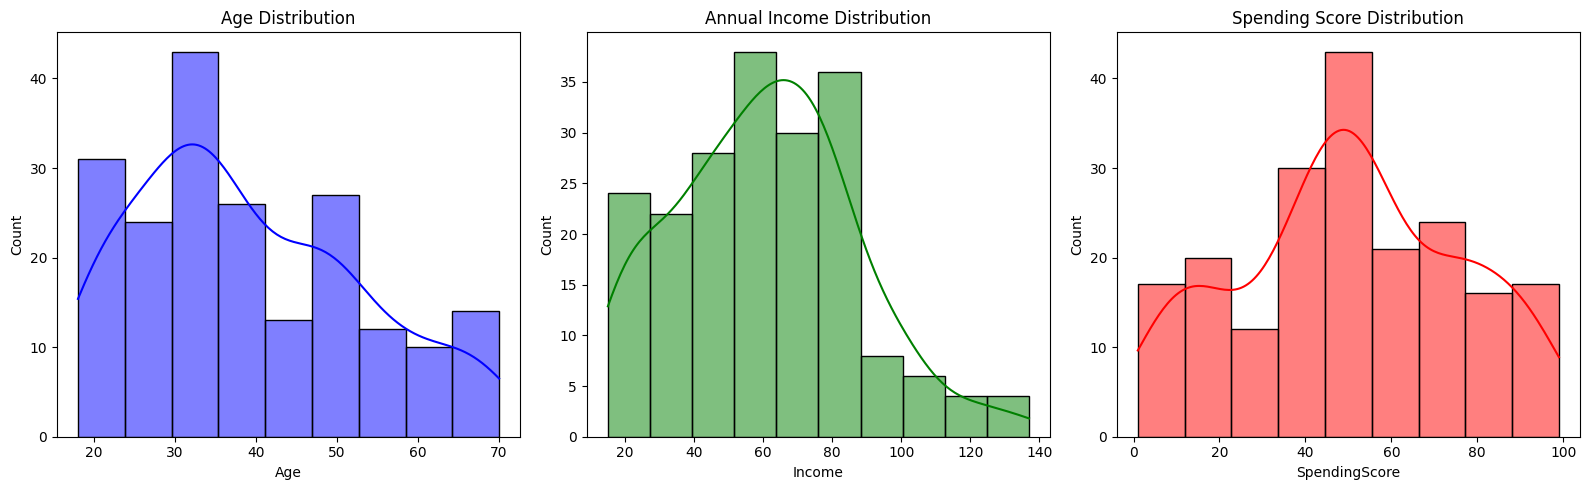

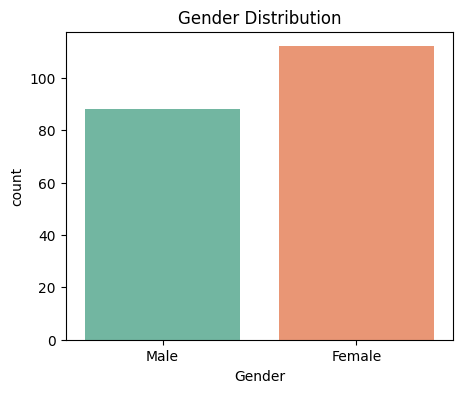

Gender
Female    112
Male       88
Name: count, dtype: int64

Percentage:
Gender
Female    56.0
Male      44.0
Name: count, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Income'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['SpendingScore'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x='Gender', data=df, 
              hue='Gender', palette='Set2', legend=False)
plt.title('Gender Distribution')
plt.show()

print(df['Gender'].value_counts())
print("\nPercentage:")
print((df['Gender'].value_counts() / len(df) * 100).round(2))


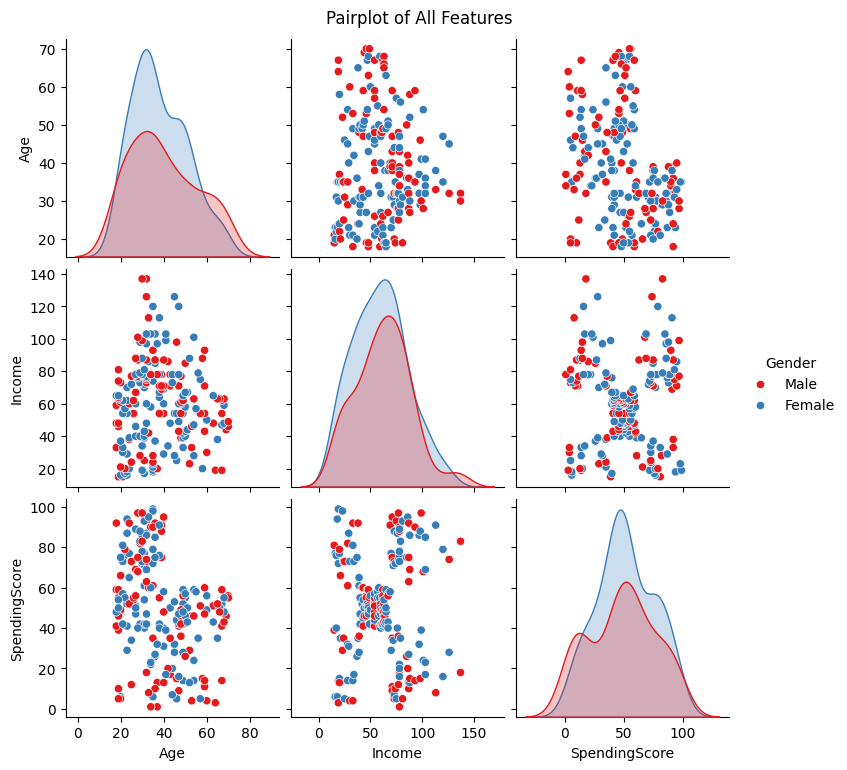

In [5]:
sns.pairplot(df.drop('ID', axis=1), hue='Gender', palette='Set1')
plt.suptitle('Pairplot of All Features', y=1.02)
plt.show()

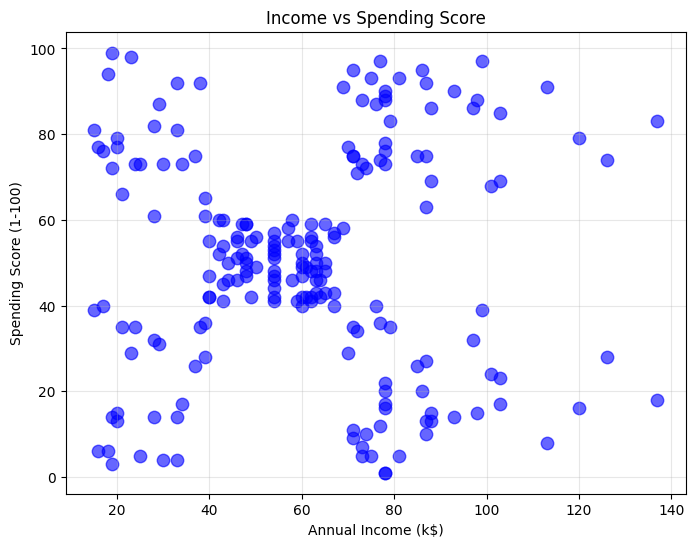

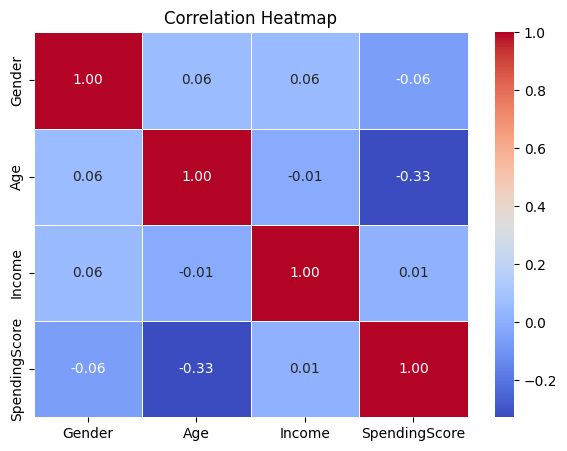

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Income'], df['SpendingScore'], 
            c='blue', alpha=0.6, s=80)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Income vs Spending Score')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
df_encoded = df.copy()
df_encoded['Gender'] = LabelEncoder().fit_transform(df['Gender'])
sns.heatmap(df_encoded.drop('ID', axis=1).corr(), 
            annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [7]:
# use Income and SpendingScore for main clustering
X_cluster = df[['Income', 'SpendingScore']].values

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Features for clustering:", ['Income', 'SpendingScore'])
print("Shape:", X_scaled.shape)


Features for clustering: ['Income', 'SpendingScore']
Shape: (200, 2)


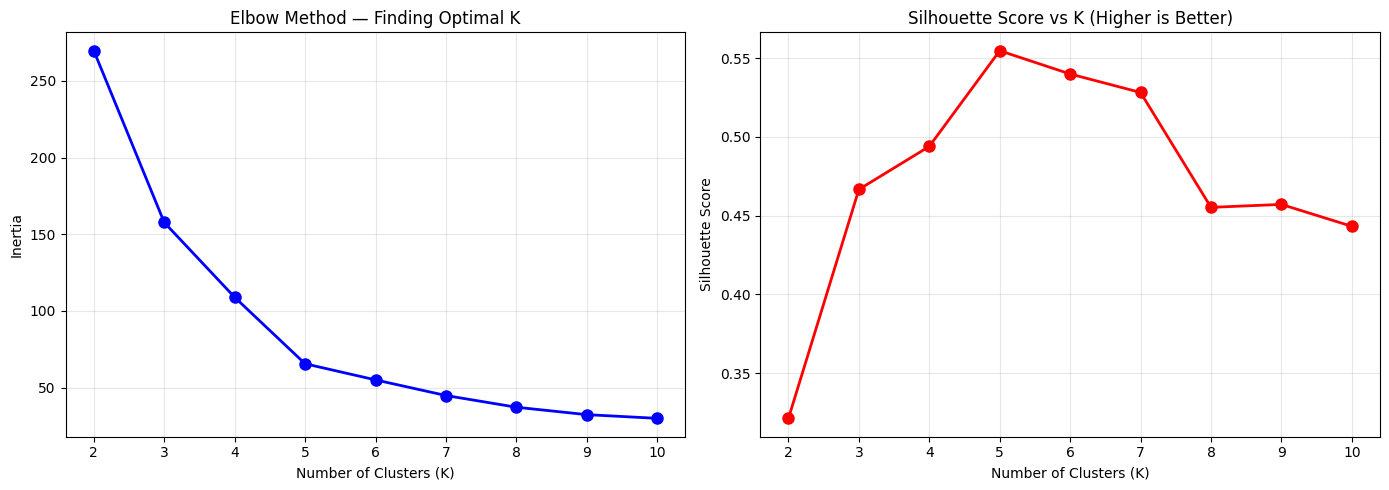

Best K by Silhouette Score: 5
Cluster distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [8]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Finding Optimal K')
axes[0].grid(True, alpha=0.3)

# silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K (Higher is Better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K by Silhouette Score: {best_k}")

# elbow and silhouette both suggest 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

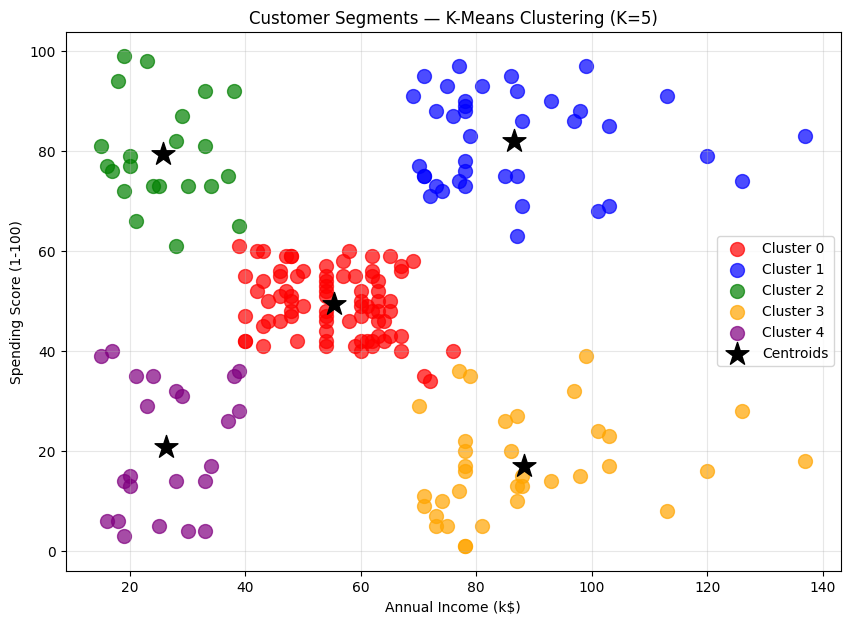

Cluster Summary:
           Age  Income  SpendingScore  Count
Cluster                                     
0        42.72   55.30          49.52     81
1        32.69   86.54          82.13     39
2        25.27   25.73          79.36     22
3        41.11   88.20          17.11     35
4        45.22   26.30          20.91     23
Segment
Regular Customers    81
Target Customers     39
Careful Spenders     35
Budget Customers     23
Impulsive Buyers     22
Name: count, dtype: int64


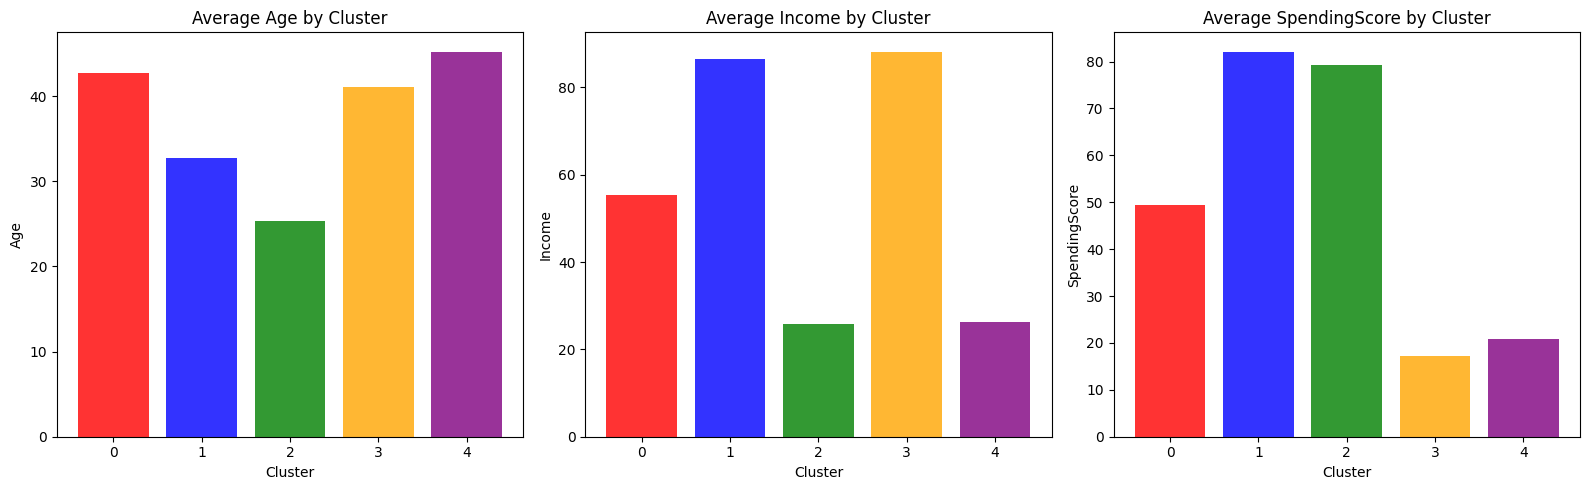

In [9]:
colors = ['red', 'blue', 'green', 'orange', 'purple']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 
                 'Cluster 3', 'Cluster 4']

plt.figure(figsize=(10, 7))

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Income'], 
                cluster_data['SpendingScore'],
                c=colors[i], label=cluster_names[i], 
                s=100, alpha=0.7)

# plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='*', s=300, 
            label='Centroids', zorder=5)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments — K-Means Clustering (K=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cluster_summary = df.groupby('Cluster')[['Age', 'Income', 'SpendingScore']].mean().round(2)
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()

print("Cluster Summary:")
print(cluster_summary)

# give meaningful names based on Income and SpendingScore
cluster_labels = {
    0: 'Regular Customers',
    1: 'Target Customers',
    2: 'Impulsive Buyers',
    3: 'Careful Spenders',
    4: 'Budget Customers'
}

df['Segment'] = df['Cluster'].map(cluster_labels)
print(df['Segment'].value_counts())




fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['Age', 'Income', 'SpendingScore']):
    cluster_means = df.groupby('Cluster')[col].mean()
    axes[i].bar(cluster_means.index, cluster_means.values, 
                color=colors, alpha=0.8)
    axes[i].set_title(f'Average {col} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


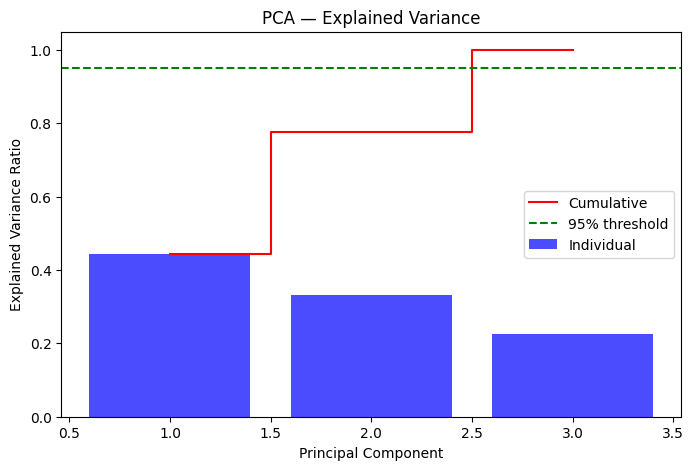

Explained variance by component:
  PC1: 44.27%  (Cumulative: 44.27%)
  PC2: 33.31%  (Cumulative: 77.57%)
  PC3: 22.43%  (Cumulative: 100.00%)


In [10]:
# use all numeric features for PCA
X_pca = df[['Age', 'Income', 'SpendingScore']].values
X_pca_scaled = StandardScaler().fit_transform(X_pca)

# fit PCA
pca = PCA()
pca.fit(X_pca_scaled)

# explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_var)+1), explained_var, 
        alpha=0.7, color='blue', label='Individual')
plt.step(range(1, len(cumulative_var)+1), cumulative_var, 
         where='mid', color='red', label='Cumulative')
plt.axhline(y=0.95, color='green', linestyle='--', 
            label='95% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA — Explained Variance')
plt.legend()
plt.show()

print("Explained variance by component:")
for i, var in enumerate(explained_var):
    print(f"  PC{i+1}: {var*100:.2f}%  (Cumulative: {cumulative_var[i]*100:.2f}%)")

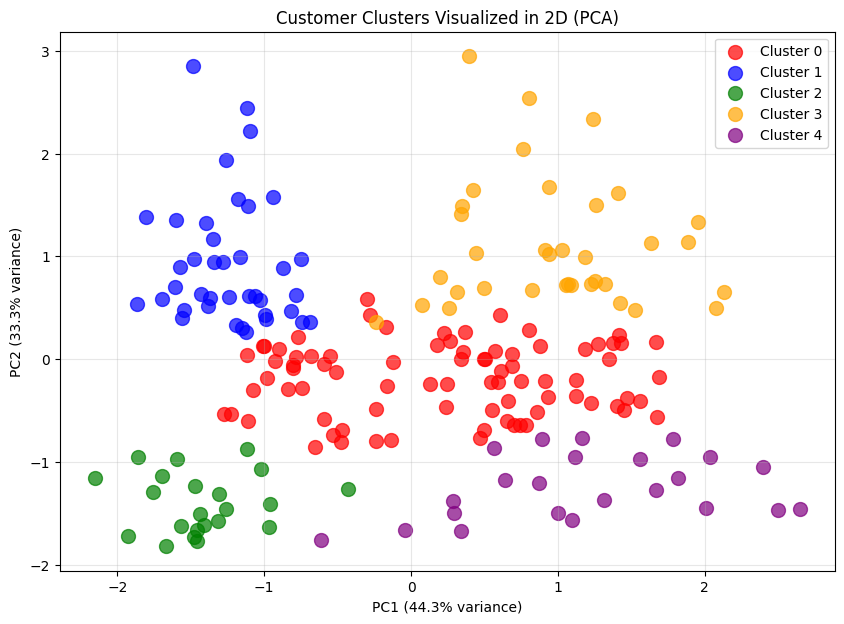

PC1 + PC2 explains: 77.6% of variance
PCA Loadings (how much each feature contributes):
                    PC1       PC2
Age            0.706382  0.030141
Income        -0.048024  0.998832
SpendingScore -0.706199 -0.037775


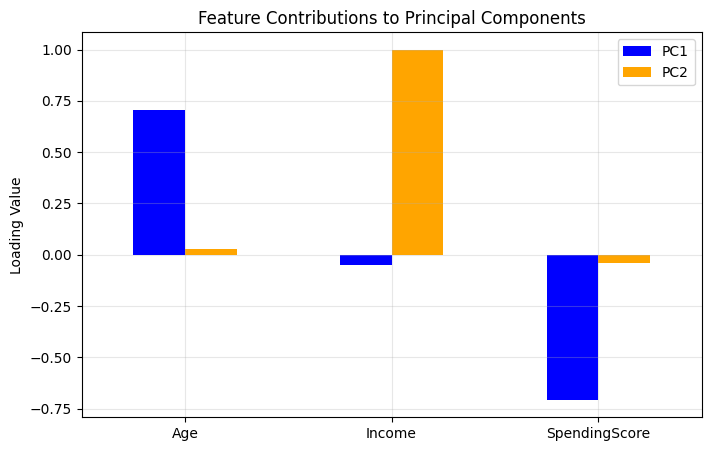

In [11]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_pca_scaled)

plt.figure(figsize=(10, 7))

for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=100, alpha=0.7)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer Clusters Visualized in 2D (PCA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"PC1 + PC2 explains: {sum(pca_2d.explained_variance_ratio_)*100:.1f}% of variance")
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=['Age', 'Income', 'SpendingScore']
)

print("PCA Loadings (how much each feature contributes):")
print(loadings)

plt.figure(figsize=(8, 5))
loadings.plot(kind='bar', ax=plt.gca(), color=['blue', 'orange'])
plt.title('Feature Contributions to Principal Components')
plt.ylabel('Loading Value')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

Number of clusters found: 7
Number of noise points: 35

Cluster distribution:
DBSCAN_Cluster
-1    35
 0    12
 1     5
 2     7
 3    88
 4    30
 5    14
 6     9
Name: count, dtype: int64


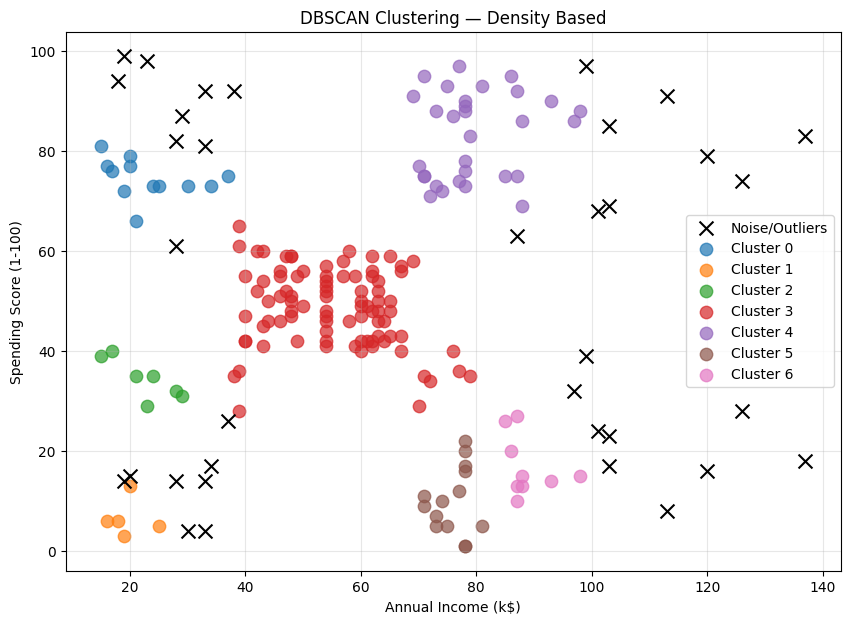

In [12]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = (df['DBSCAN_Cluster'] == -1).sum()

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"\nCluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

plt.figure(figsize=(10, 7))

# plot noise points first
noise = df[df['DBSCAN_Cluster'] == -1]
plt.scatter(noise['Income'], noise['SpendingScore'],
            c='black', marker='x', s=100, 
            label='Noise/Outliers', zorder=5)

# plot clusters
unique_clusters = sorted(df[df['DBSCAN_Cluster'] != -1]['DBSCAN_Cluster'].unique())
for cluster in unique_clusters:
    cluster_data = df[df['DBSCAN_Cluster'] == cluster]
    plt.scatter(cluster_data['Income'], 
                cluster_data['SpendingScore'],
                label=f'Cluster {cluster}', 
                s=80, alpha=0.7)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clustering — Density Based')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

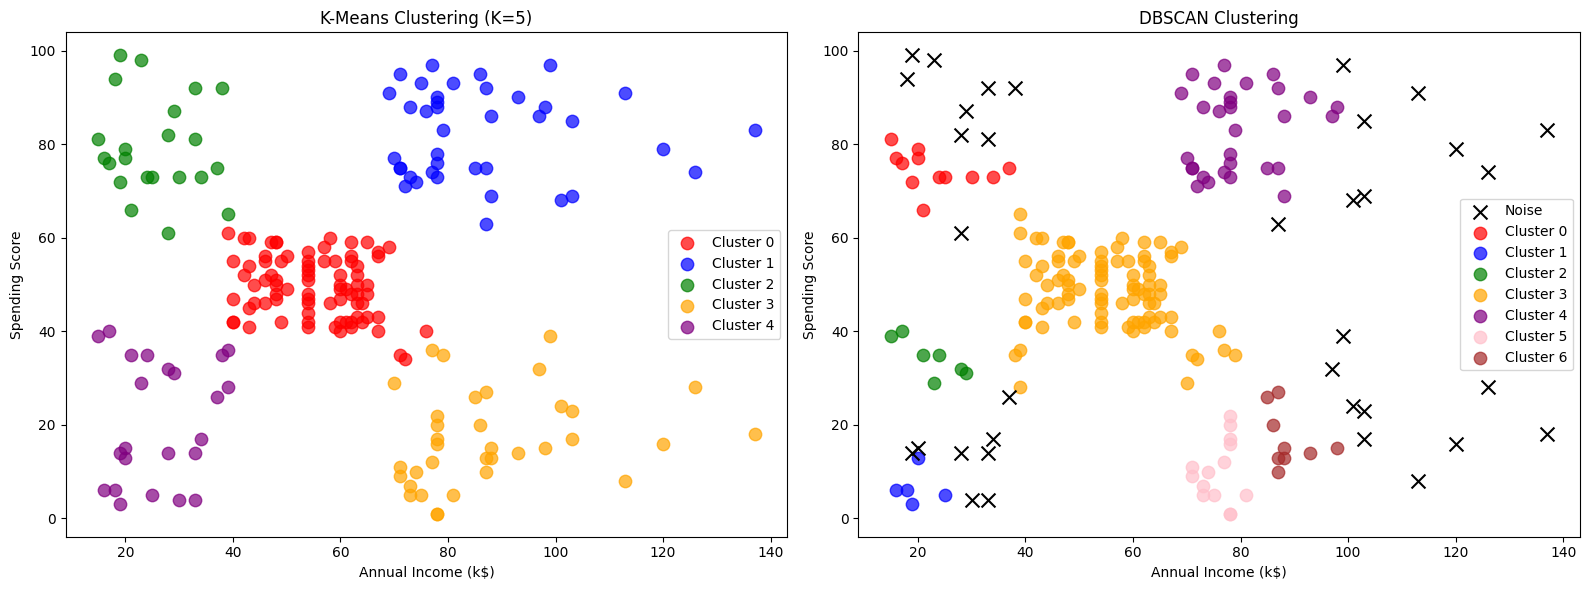

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KMeans
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    axes[0].scatter(cluster_data['Income'],
                    cluster_data['SpendingScore'],
                    c=colors[i], label=f'Cluster {i}',
                    s=80, alpha=0.7)
axes[0].set_title('K-Means Clustering (K=5)')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].legend()

# DBSCAN
dbscan_colors = ['red', 'blue', 'green', 'orange', 
                  'purple', 'pink', 'brown']
noise = df[df['DBSCAN_Cluster'] == -1]
axes[1].scatter(noise['Income'], noise['SpendingScore'],
                c='black', marker='x', s=100,
                label='Noise', zorder=5)

for i, cluster in enumerate(unique_clusters):
    cluster_data = df[df['DBSCAN_Cluster'] == cluster]
    axes[1].scatter(cluster_data['Income'],
                    cluster_data['SpendingScore'],
                    c=dbscan_colors[i % len(dbscan_colors)],
                    label=f'Cluster {cluster}',
                    s=80, alpha=0.7)
axes[1].set_title('DBSCAN Clustering')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# use KMeans clusters as labels for SVM
X_svm = df[['Age', 'Income', 'SpendingScore']].values
y_svm = df['Cluster'].values

# scale
scaler_svm = StandardScaler()
X_svm_scaled = scaler_svm.fit_transform(X_svm)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_svm_scaled, y_svm,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

#Training
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_acc = (svm_pred == y_test).mean()

print(f"SVM Accuracy: {svm_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

X_train shape: (160, 3)
X_test shape: (40, 3)
SVM Accuracy: 97.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      0.91      0.95        11
           4       1.00      1.00      1.00         3

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



<Figure size 700x600 with 0 Axes>

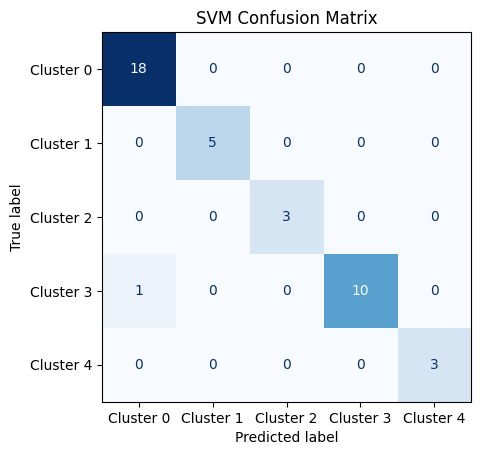

linear    : 96.00% (±4.64%)
rbf       : 96.00% (±2.00%)
poly      : 90.00% (±4.47%)
sigmoid   : 94.50% (±6.00%)


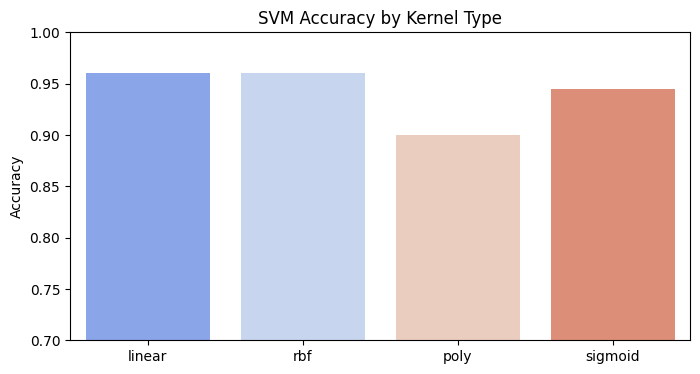

In [15]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[f'Cluster {i}' for i in range(5)])
disp.plot(cmap='Blues', colorbar=False)
plt.title('SVM Confusion Matrix')
plt.show()
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_scores = []

for kernel in kernels:
    svm_k = SVC(kernel=kernel, random_state=42)
    scores = cross_val_score(svm_k, X_svm_scaled, y_svm, cv=5)
    kernel_scores.append(scores.mean())
    print(f"{kernel:10s}: {scores.mean()*100:.2f}% (±{scores.std()*100:.2f}%)")

plt.figure(figsize=(8, 4))
sns.barplot(x=kernels, y=kernel_scores,
            hue=kernels, palette='coolwarm', legend=False)
plt.title('SVM Accuracy by Kernel Type')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.show()

In [16]:
# parameter distribution to sample from
param_dist = {
    'C': uniform(0.1, 100),          # sample C from 0.1 to 100.1
    'gamma': uniform(0.001, 1),      # sample gamma from 0.001 to 1.001
    'kernel': ['rbf', 'linear', 'poly']
}

random_search = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_dist,
    n_iter=50,           # try 50 random combinations
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest Parameters:", random_search.best_params_)
print(f"Best CV Score: {random_search.best_score_*100:.2f}%")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'C': np.float64(5.741157902710025), 'gamma': np.float64(0.7229987722668247), 'kernel': 'linear'}
Best CV Score: 99.38%


Default SVM Accuracy:  97.50%
Tuned SVM Accuracy:    95.00%

Improvement: -2.50%

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        18
           1       1.00      1.00      1.00         5
           2       1.00      0.67      0.80         3
           3       1.00      0.91      0.95        11
           4       1.00      1.00      1.00         3

    accuracy                           0.95        40
   macro avg       0.98      0.92      0.94        40
weighted avg       0.96      0.95      0.95        40



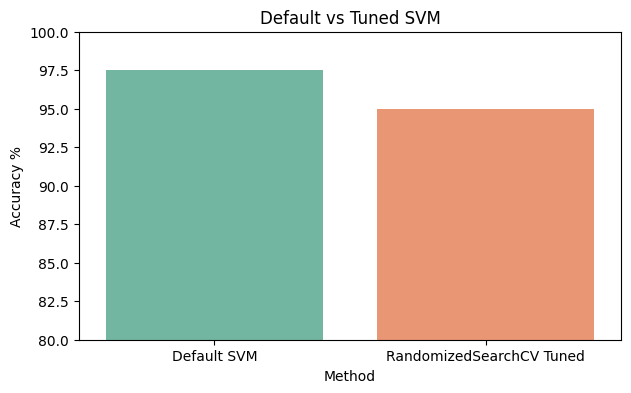

In [17]:
best_svm = random_search.best_estimator_
tuned_pred = best_svm.predict(X_test)
tuned_acc = (tuned_pred == y_test).mean()

print(f"Default SVM Accuracy:  {svm_acc*100:.2f}%")
print(f"Tuned SVM Accuracy:    {tuned_acc*100:.2f}%")
print(f"\nImprovement: {(tuned_acc - svm_acc)*100:.2f}%")

print("\nClassification Report (Tuned SVM):")
print(classification_report(y_test, tuned_pred))

comparison = pd.DataFrame({
    'Method': ['Default SVM', 'RandomizedSearchCV Tuned'],
    'Accuracy': [svm_acc*100, tuned_acc*100]
})

plt.figure(figsize=(7, 4))
sns.barplot(x='Method', y='Accuracy',
            hue='Method', data=comparison,
            palette='Set2', legend=False)
plt.title('Default vs Tuned SVM')
plt.ylim(80, 100)
plt.ylabel('Accuracy %')
plt.show()

In [18]:
print("=" * 55)
print("       UNSUPERVISED LEARNING — FINAL SUMMARY")
print("=" * 55)

print("\n📊 DATASET")
print(f"   Customers: {len(df)}")
print(f"   Features: Age, Income, SpendingScore")

print("\n🔵 K-MEANS CLUSTERING")
print(f"   Optimal K: 5 clusters")
print(f"   Silhouette Score: {silhouette_score(X_scaled, kmeans.labels_):.4f}")

print("\n🟢 PCA")
print(f"   PC1 + PC2 explains: {sum(pca_2d.explained_variance_ratio_)*100:.1f}% variance")

print("\n🔴 DBSCAN")
print(f"   Clusters found: {n_clusters}")
print(f"   Noise points: {n_noise}")

print("\n🟡 SVM CLASSIFICATION")
print(f"   Default SVM Accuracy:  {svm_acc*100:.2f}%")
print(f"   Tuned SVM Accuracy:    {tuned_acc*100:.2f}%")
print(f"   Best Kernel: {random_search.best_params_['kernel']}")
print(f"   Best C: {random_search.best_params_['C']:.4f}")





       UNSUPERVISED LEARNING — FINAL SUMMARY

📊 DATASET
   Customers: 200
   Features: Age, Income, SpendingScore

🔵 K-MEANS CLUSTERING
   Optimal K: 5 clusters
   Silhouette Score: 0.5547

🟢 PCA
   PC1 + PC2 explains: 77.6% variance

🔴 DBSCAN
   Clusters found: 7
   Noise points: 35

🟡 SVM CLASSIFICATION
   Default SVM Accuracy:  97.50%
   Tuned SVM Accuracy:    95.00%
   Best Kernel: linear
   Best C: 5.7412


In [19]:
segment_names = {
    0: 'Check cluster summary to label',
    1: 'Check cluster summary to label',
    2: 'Check cluster summary to label',
    3: 'Check cluster summary to label',
    4: 'Check cluster summary to label'
}

print("\nCluster Profiles:")
print(df.groupby('Cluster')[['Age', 'Income', 'SpendingScore']].mean().round(1))
print("\nNote: After seeing these numbers label each cluster as:")
print("- High Income High Spend = 'Target Customers'")
print("- High Income Low Spend  = 'Careful Spenders'")
print("- Low Income High Spend  = 'Impulsive Buyers'")
print("- Low Income Low Spend   = 'Budget Customers'")
print("- Average Income Average = 'Regular Customers'")


Cluster Profiles:
          Age  Income  SpendingScore
Cluster                             
0        42.7    55.3           49.5
1        32.7    86.5           82.1
2        25.3    25.7           79.4
3        41.1    88.2           17.1
4        45.2    26.3           20.9

Note: After seeing these numbers label each cluster as:
- High Income High Spend = 'Target Customers'
- High Income Low Spend  = 'Careful Spenders'
- Low Income High Spend  = 'Impulsive Buyers'
- Low Income Low Spend   = 'Budget Customers'
- Average Income Average = 'Regular Customers'
